# MeloWave - Mission 1 : analyse du catalogue


## 1. Chargement des données

In [1]:
import pandas as pd
import numpy as np

#forcer l'affichage complet
pd.set_option("display.max_columns",30)
pd.set_option("display.width",160)

CHEMIN = "../data/spotify-tracks-dataset-detailed.csv"

df = pd.read_csv(CHEMIN)

#je stocke le nombre de lignes de départ tout de suite pour comparer facilement a la fin
n_source = len(df)

print(f"{n_source} lignes, {df.shape[1]} colonnes")

114000 lignes, 20 colonnes


In [2]:
df.head()

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   track_id          114000 non-null  object 
 1   artists           113999 non-null  object 
 2   album_name        113999 non-null  object 
 3   track_name        113999 non-null  object 
 4   popularity        114000 non-null  int64  
 5   duration_ms       114000 non-null  int64  
 6   explicit          114000 non-null  bool   
 7   danceability      114000 non-null  float64
 8   energy            114000 non-null  float64
 9   key               114000 non-null  int64  
 10  loudness          114000 non-null  float64
 11  mode              114000 non-null  int64  
 12  speechiness       114000 non-null  float64
 13  acousticness      114000 non-null  float64
 14  instrumentalness  114000 non-null  float64
 15  liveness          114000 non-null  float64
 16  valence           11

On constate que toutes les colonnes sont à 114 000 non-null, sauf artists, album_name et track_name à 113 999.

### Ce que contient chaque colonne

Les définitions viennent du mail de Camille.

| Colonne | Ce que c'est |
|---|---|
| `track_id` | identifiant Spotify du morceau |
| `artists` | artiste ou artistes, séparés par un `;` quand il y a un featuring |
| `album_name`, `track_name` | nom de l'album et du morceau |
| `popularity` | score de 0 à 100 calculé par Spotify sur les écoutes récentes. Les écoutes d'hier pèsent plus que celles d'il y a trois ans |
| `duration_ms` | durée en millisecondes |
| `explicit` | vrai ou faux, paroles signalées explicites par la maison de disques |
| `danceability` | 0 à 1, à quel point le morceau se prête à la danse (tempo, stabilité du rythme, force du beat) |
| `energy` | 0 à 1, intensité ressentie. Un morceau rapide et bruyant monte vers 1 |
| `key`, `mode` | tonalité et mode (majeur ou mineur) |
| `loudness` | volume moyen en décibels, en général entre -60 et 0 |
| `speechiness` | 0 à 1, présence de parole plutôt que de chant |
| `acousticness` | 0 à 1, probabilité que le morceau soit acoustique et pas produit électroniquement |
| `instrumentalness` | 0 à 1, probabilité qu'il n'y ait pas de voix |
| `liveness` | 0 à 1, présence d'un public, donc enregistrement live |
| `valence` | 0 à 1, humeur du morceau. Proche de 1 il sonne joyeux, proche de 0 il sonne triste ou en colère |
| `tempo` | battements par minute |
| `time_signature` | signature rythmique (3, 4, 5...) |
| `track_genre` | genre auquel Spotify rattache le morceau dans cette ligne |


## 2. Audit qualité

Avant de toucher quoi que ce soit, je regarde ce qui cloche.

In [4]:
# valeurs manquantes
manquants = df.isna().sum()
print(manquants[manquants > 0] if manquants.sum() else "aucune valeur manquante")

artists       1
album_name    1
track_name    1
dtype: int64


In [5]:
# lignes strictement identiques sur toutes les colonnes
n_doublons = df.duplicated().sum()

print(f"il y a {n_doublons} lignes strictement identiques")
df[df.duplicated(keep=False)].sort_values("track_id").head(4)

il y a 450 lignes strictement identiques


,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
52766,00JZ83w0Qm09f4PwWj06sM,George Jones,With Love,A Good Year For The Roses,12,190546,False,0.491,0.334,11,-9.684,1,0.0287,0.659,0.000016,0.116,0.2490,91.674,4,honky-tonk
52714,00JZ83w0Qm09f4PwWj06sM,George Jones,With Love,A Good Year For The Roses,12,190546,False,0.491,0.334,11,-9.684,1,0.0287,0.659,0.000016,0.116,0.2490,91.674,4,honky-tonk
39275,02KmEChUwcjxG3G29kbLFT,Hans Zimmer;Henning Lohner;Martin Tillman;Fiac...,Hans Zimmer: Epic Scores,Shelter Mountain,16,250520,False,0.144,0.262,9,-21.228,1,0.0641,0.876,0.755000,0.144,0.0345,94.430,4,german
39307,02KmEChUwcjxG3G29kbLFT,Hans Zimmer;Henning Lohner;Martin Tillman;Fiac...,Hans Zimmer: Epic Scores,Shelter Mountain,16,250520,False,0.144,0.262,9,-21.228,1,0.0641,0.876,0.755000,0.144,0.0345,94.430,4,german


### Des track_id reviennent-ils plusieurs fois ?

Reste un point à regarder : est-ce que le même morceau revient plusieurs fois dans le fichier,
et si oui pourquoi ?

In [6]:
# combien de morceaux reviennent plusieurs fois, et pour quelle raison
n_id_dupes = df.duplicated(subset=["track_id"]).sum()
print(f"track_id dupliques : {n_id_dupes}")
print(f"track_id uniques   : {df.track_id.nunique()} sur {len(df)} lignes")

genres_par_track = df.groupby("track_id").track_genre.nunique()
print(f"morceaux presents sur plusieurs genres : {(genres_par_track > 1).sum()}")

track_id dupliques : 24259
track_id uniques   : 89741 sur 114000 lignes


morceaux presents sur plusieurs genres : 16299


In [7]:
# a quoi ressemblent ces doublons ? j'affiche le morceau qui revient le plus souvent
exemple = genres_par_track.idxmax()
df[df.track_id == exemple][["track_name", "artists", "track_genre", "popularity", "energy", "tempo"]]

,track_name,artists,track_genre,popularity,energy,tempo
8315,Baby Blue - Remastered 2010,Badfinger,blues,67,0.876,124.431
19759,Baby Blue - Remastered 2010,Badfinger,country,67,0.876,124.431
34728,Baby Blue - Remastered 2010,Badfinger,folk,67,0.876,124.431
62226,Baby Blue - Remastered 2010,Badfinger,j-pop,67,0.876,124.431
63087,Baby Blue - Remastered 2010,Badfinger,j-rock,67,0.876,124.431
82064,Baby Blue - Remastered 2010,Badfinger,power-pop,67,0.876,124.431
84129,Baby Blue - Remastered 2010,Badfinger,psych-rock,67,0.876,124.431
99727,Baby Blue - Remastered 2010,Badfinger,singer-songwriter,67,0.876,124.431
102732,Baby Blue - Remastered 2010,Badfinger,songwriter,67,0.876,124.431


24 259 lignes portent un identifiant déjà vu plus haut. Il reste donc 89 741 morceaux différents
pour 114 000 lignes, et 16 299 d'entre eux apparaissent dans plusieurs genres.

La tentation serait de faire un `drop_duplicates("track_id")` et de passer à la suite. Ce serait
une erreur : ici un morceau classé dans plusieurs genres apparaît une fois par genre. Si je
supprime, je casse toute l'analyse par genre.

Baby Blue de Badfinger le montre bien : neuf lignes, seul le genre change, l'énergie et le tempo
ne bougent pas d'un chiffre. C'est différent des 450 lignes vues juste avant, ou même le genre
était identique.

Avant de trancher, je vérifie sur tout le catalogue que les lignes d'un même morceau ne se
contredisent jamais.


In [8]:
# est-ce que les caracteristiques audio varient pour un meme morceau ?
audio = ["duration_ms", "danceability", "energy", "loudness", "speechiness",
         "acousticness", "instrumentalness", "liveness", "valence", "tempo"]

variations = df.groupby("track_id")[audio + ["popularity"]].nunique().max()
print(variations)

duration_ms         1
danceability        1
energy              1
loudness            1
speechiness         1
acousticness        1
instrumentalness    1
liveness            1
valence             1
tempo               1
popularity          2
dtype: int64


In [9]:
# la popularite est la seule a bouger : de combien ?
pop = df.groupby("track_id").popularity.agg(["nunique", "min", "max"])
pop_variable = pop[pop["nunique"] > 1]

print(f"{len(pop_variable)} morceaux ont une popularite qui varie selon la ligne")
ecart = pop_variable["max"] - pop_variable["min"]
print(f"ecart moyen : {ecart.mean():.1f} points | ecart max : {ecart.max()} points")

720 morceaux ont une popularite qui varie selon la ligne
ecart moyen : 1.7 points | ecart max : 44 points


Le tableau n'affiche que des 1, sauf la popularité qui est à 2.

Un 1 veut dire que sur les 89 741 morceaux du fichier, la variable ne prend jamais qu'une seule
valeur par morceau. Les neuf lignes de Baby Blue disent donc la même chose :
même durée, même énergie, même tempo.

Seule la popularité bouge, et sur 720 morceaux seulement, avec 1,7 point d'écart en moyenne. Les
relevés ont sans doute été faits à des dates différentes, et la note Spotify évolue dans le temps.

Je peux donc garder les 16 299 morceaux multi-genres sans risque : leurs lignes ne se contredisent
pas.


### Des valeurs impossibles ?

Dernier point avant de nettoyer. Le contrôle le plus rapide pour repérer une valeur aberrante,
c'est de regarder les deux extrémités de chaque variable numérique : son minimum et son maximum.
Un seul des deux ne montrerait que la moitié des erreurs possibles.


In [10]:
# les deux extremites de chaque variable numerique, d'un coup
df.select_dtypes("number").agg(["min", "max"]).T

,min,max
popularity,0.000,100.000
duration_ms,0.000,5237295.000
danceability,0.000,0.985
energy,0.000,1.000
key,0.000,11.000
loudness,-49.531,4.532
mode,0.000,1.000
speechiness,0.000,0.965
acousticness,0.000,0.996
instrumentalness,0.000,1.000


**Du côté des minimums**, presque tout descend à 0, c'est normal pour les variables 0-1 et pour les codes
`key` et `mode`. Quatre colonnes posent question : **la durée, le tempo, la signature rythmique et la
popularité**. Les trois premières sont impossibles en musique. La popularité à 0, elle, est une
vraie information.

**Du côté des maximums**, le loudness monte à +4,5 alors que Camille annonce -60 à 0 dB. Ce n'est pas forcément une erreur, mais je le note. La durée maximale, **5 237 295** millisecondes soit **87 minutes**. Aucun des deux ne semble faux, je les note.

Je compte les lignes concernées, popularités à zéro comprises.

In [11]:
# combien de lignes sont concernees par ces zeros
for col in ["duration_ms", "tempo", "time_signature"]:
    n = (df[col] == 0).sum()
    print(f"{col} = 0 : {n} lignes ({n/len(df):.2%})")

n_pop0 = (df.popularity == 0).sum()
print(f"\npopularity = 0 : {n_pop0} lignes ({n_pop0/len(df):.1%})")

duration_ms = 0 : 1 lignes (0.00%)
tempo = 0 : 157 lignes (0.14%)
time_signature = 0 : 163 lignes (0.14%)

popularity = 0 : 16020 lignes (14.1%)


### Ce que je retiens de l'audit

- Une seule ligne a ses trois champs texte vides. Elle dure aussi 0 milliseconde, donc elle
  n'identifie rien et ne mesure rien : je la retire.
- 450 lignes sont strictement identiques. Peut-être une erreur de collecte, je les retire aussi.
- Les 16 299 morceaux présents sur plusieurs genres ne sont pas des doublons. Les caractéristiques
  audio sont identiques d'une ligne à l'autre, seule la popularité bouge un peu sur 720 morceaux,
  sur des relevés faits à des moments différents. Je garde ces lignes.
- Un tempo à 0 ou une signature rythmique à 0 sont impossibles en musique. Ce sont des mesures
  ratées, pas des vrais zéros. Je les marque au lieu de les supprimer, et je les écarte seulement
  dans les analyses qui portent sur ces variables.
- Les 16 020 lignes à popularité 0, soit 14,1 % du fichier, c'est différent : un morceau qui n'a
  jamais été écouté a bien une popularité nulle. C'est une vraie information, je la garde et j'en
  tiendrai compte en lisant les distributions.


## 3. Nettoyage

Je note le nombre de lignes avant et après chaque opération, pour pouvoir dire exactement ce que
j'ai touché. Je travaille sur une copie, le fichier de départ reste intact.


In [12]:
# je note chaque operation dans un journal, pour pouvoir dire plus tard ce que j'ai touche
journal = []
df_genre = df.copy()

# 1. les lignes strictement identiques : erreur de collecte, je les retire
avant = len(df_genre)
df_genre = df_genre.drop_duplicates()
journal.append({"operation": "suppression des lignes strictement identiques",
                "avant": avant, "apres": len(df_genre), "retirees": avant - len(df_genre)})

# 2. la ligne sans titre, sans artiste et sans album : elle dure aussi 0 milliseconde,
#    donc elle n'identifie rien et ne mesure rien. Je la retire.
avant = len(df_genre)
df_genre = df_genre.dropna(subset=["artists", "album_name", "track_name"])
journal.append({"operation": "suppression de la ligne sans titre ni duree",
                "avant": avant, "apres": len(df_genre), "retirees": avant - len(df_genre)})

# 3. je marque les mesures impossibles au lieu de les jeter
df_genre["mesure_douteuse"] = (
    (df_genre.tempo == 0) | (df_genre.time_signature == 0) | (df_genre.duration_ms == 0)
)
journal.append({"operation": f"{df_genre.mesure_douteuse.sum()} lignes marquees 'mesure douteuse'",
                "avant": len(df_genre), "apres": len(df_genre), "retirees": 0})

# 4. duree en secondes, plus lisible que des millisecondes
df_genre["duree_s"] = df_genre.duration_ms / 1000
journal.append({"operation": "duree convertie en secondes",
                "avant": len(df_genre), "apres": len(df_genre), "retirees": 0})

pd.DataFrame(journal)

,operation,avant,apres,retirees
0,suppression des lignes strictement identiques,114000,113550,450
1,suppression de la ligne sans titre ni duree,113550,113549,1
2,163 lignes marquees 'mesure douteuse',113549,113549,0
3,duree convertie en secondes,113549,113549,0


### Le bilan du nettoyage

Le journal dit ce que j'ai fait opération par opération. Reste le résultat global : combien de
lignes au départ, combien il en reste, et ce que ça représente. C'est ici que sert le `n_source`
mis de côté dans la toute première cellule.


In [13]:
# combien de lignes au depart, combien il en reste

n_final = len(df_genre)
recap = pd.DataFrame({
    "etape": ["lignes depart", "lignes conservees", "lignes retirees"],
    "nombre": [n_source, n_final, n_source - n_final],
    "part": ["100.0%", f"{n_final/n_source:.1%}", f"{(n_source-n_final)/n_source:.1%}"],
})
recap

,etape,nombre,part
0,lignes depart,114000,100.0%
1,lignes conservees,113549,99.6%
2,lignes retirees,451,0.4%


113 549 lignes conservées sur 114 000, soit 0,4 % retirées. C'est le seul
chiffre à retenir du nettoyage : je n'ai pratiquement rien jeté. 

### Deux tableaux plutôt qu'un

Mes 113 549 lignes sont propres, mais elles ne répondent pas à toutes les questions. Baby Blue y
compte encore neuf fois : une durée moyenne calculée là-dessus serait tirée vers le haut par les
morceaux rangés dans beaucoup de genres.

Si je ne garde qu'une ligne par morceau, je perds la possibilité de comparer les genres.

Je fabrique donc les deux :

- `df_genre` : une ligne = un morceau dans un genre. Pour comparer les genres entre eux.
- `df_morceaux` : une ligne = un morceau. Pour les distributions et les classements.


In [14]:
# une ligne par morceau, au lieu d'une ligne par morceau et par genre
df_morceaux = df_genre.drop_duplicates("track_id").copy()

# la popularite est la seule variable qui varie : je garde la meilleure valeur
meilleure_pop = df_genre.groupby("track_id").popularity.max()
df_morceaux["popularity"] = df_morceaux.track_id.map(meilleure_pop)

print(f"df_genre    : {len(df_genre)} lignes")
print(f"df_morceaux : {len(df_morceaux)} lignes")

df_genre    : 113549 lignes
df_morceaux : 89740 lignes


89 740 morceaux uniques contre 113 549 lignes.

À partir d'ici je décris le catalogue sur df_morceaux et je compare les genres sur df_genre.
Je le précise à chaque fois.


## 4. Le catalogue en chiffres

Camille veut un état des lieux chiffré. Je regarde d'abord la forme des variables, puis les
classements, puis les profils sonores par genre.

Une précision qui compte pour tout ce qui suit : je travaille sur `df_morceaux` dès que je décris
le catalogue (un morceau ne doit compter qu'une fois dans une moyenne) et sur `df_genre` dès que je
compare des genres entre eux.

In [15]:
#Reglages d'affichage et liste des variables audio, valables pour tout le reste du notebook
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

AUDIO = ["danceability", "energy", "loudness", "speechiness", "acousticness",
         "instrumentalness", "liveness", "valence", "tempo", "duree_s"]

In [16]:
# statistiques descriptives des variables numeriques
df_morceaux[AUDIO + ["popularity"]].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
danceability,89740.0,0.56,0.18,0.00,0.45,0.58,0.69,0.98
energy,89740.0,0.63,0.26,0.00,0.46,0.68,0.85,1.00
loudness,89740.0,-8.50,5.22,-49.53,-10.32,-7.18,-5.11,4.53
speechiness,89740.0,0.09,0.11,0.00,0.04,0.05,0.09,0.96
acousticness,89740.0,0.33,0.34,0.00,0.02,0.19,0.62,1.00
instrumentalness,89740.0,0.17,0.32,0.00,0.00,0.00,0.10,1.00
liveness,89740.0,0.22,0.19,0.00,0.10,0.13,0.28,1.00
valence,89740.0,0.47,0.26,0.00,0.25,0.46,0.68,1.00
tempo,89740.0,122.06,30.12,0.00,99.26,122.01,140.08,243.37
duree_s,89740.0,229.14,112.95,8.59,173.04,213.30,264.29,5237.30


In [17]:
# et du cote des variables categorielles
for col in ["track_genre", "artists", "explicit", "mode", "time_signature"]:
    print(col, ":", df_genre[col].nunique(), "valeurs differentes,",
          "la plus frequente :", df_genre[col].mode()[0])

track_genre : 114 valeurs differentes, la plus frequente : acoustic
artists : 31437 valeurs differentes, la plus frequente : The Beatles
explicit : 2 valeurs differentes, la plus frequente : False
mode : 2 valeurs differentes, la plus frequente : 1
time_signature : 5 valeurs differentes, la plus frequente : 4


Le morceau type dure 213 secondes, soit 3 min 33. La moyenne est à 229 : l'écart annonce déjà que
quelques morceaux très longs tirent vers le haut.

Le tempo médian est à 122 battements par minute, et la moitié du catalogue tient entre 99 et 140.
C'est resserré.

Trois variables sont très basses : `speechiness` (médiane 0,05), `instrumentalness` (0,00) et
`acousticness` (0,19). Le catalogue est surtout fait de morceaux chantés et produits
électroniquement.

La popularité médiane est de 33 sur 100, et un quart des morceaux est en dessous de 19.


### Distributions des variables audio

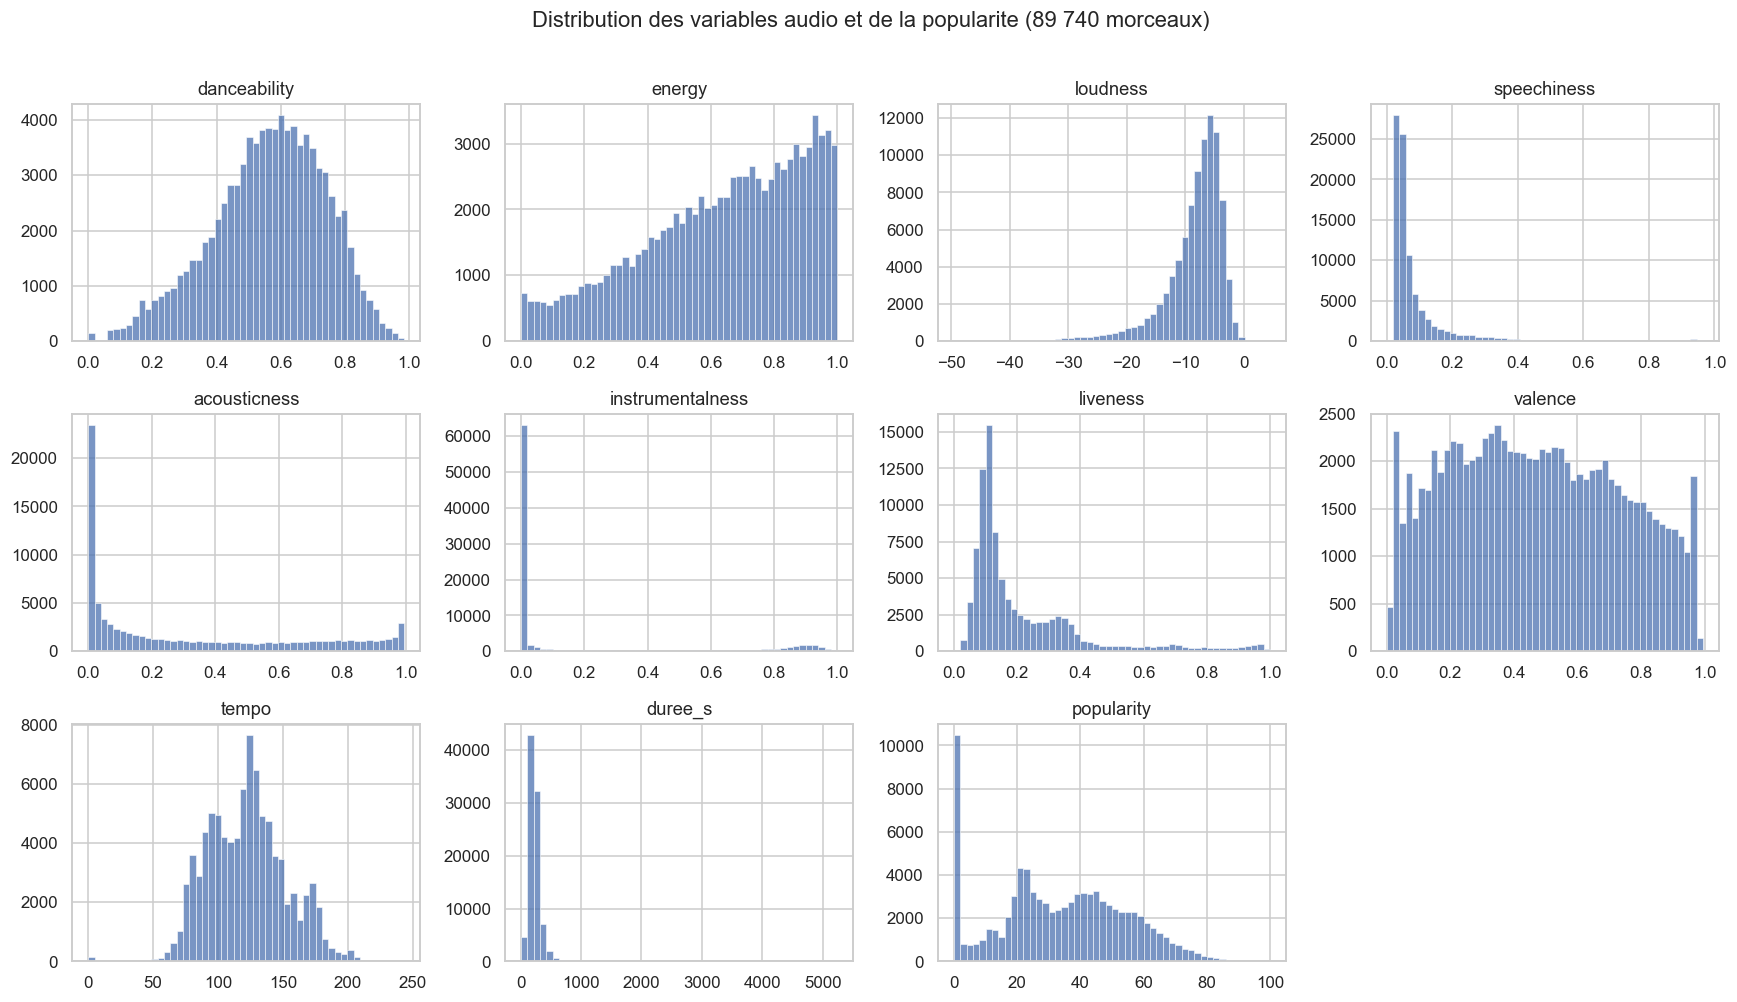

In [18]:
# la forme de chaque variable, en un coup d'oeil
fig, axes = plt.subplots(3, 4, figsize=(16, 9))
for ax, col in zip(axes.flat, AUDIO + ["popularity"]):
    sns.histplot(df_morceaux[col], bins=50, ax=ax, color="#4C72B0")
    ax.set_title(col)
    ax.set_xlabel("")
    ax.set_ylabel("")
axes.flat[-1].axis("off")
fig.suptitle("Distribution des variables audio et de la popularite (89 740 morceaux)", y=1.01)
plt.tight_layout()
plt.show()

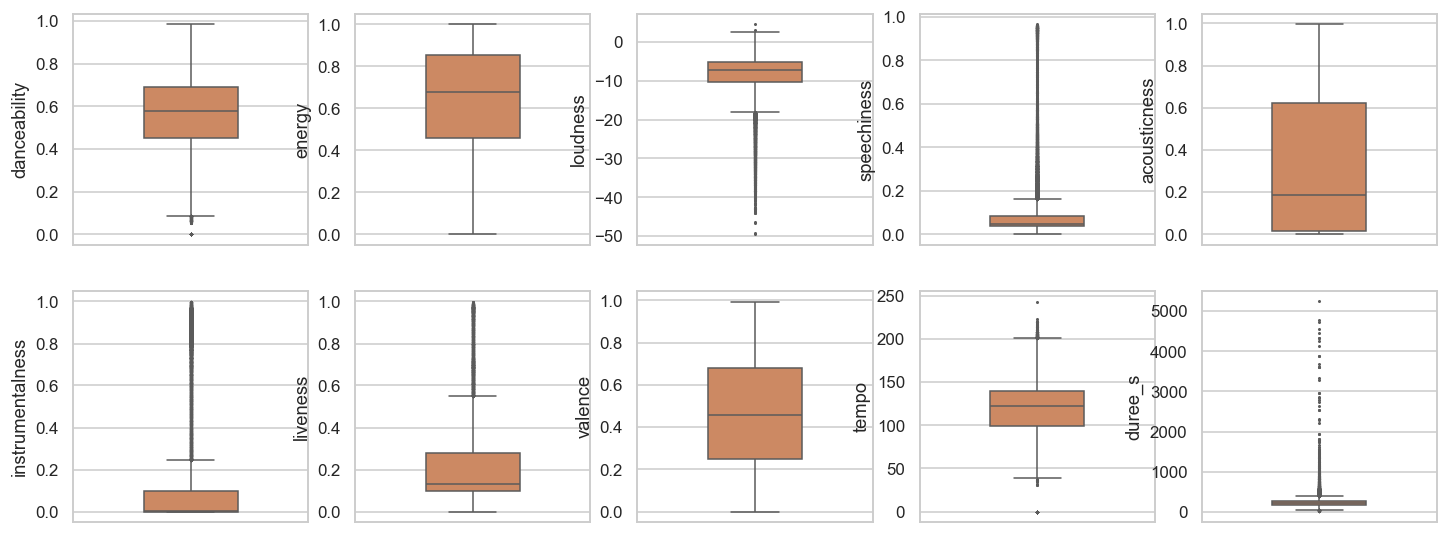

In [19]:
# les boites a moustaches, plus lisibles pour reperer les valeurs extremes
fig, axes = plt.subplots(2, 5, figsize=(16, 6))
for ax, col in zip(axes.flat, AUDIO):
    sns.boxplot(y=df_morceaux[col], ax=ax, color="#DD8452", width=.4, fliersize=1)

Les histogrammes montrent la forme à l'oeil. Je la chiffre maintenant.

In [20]:
# asymetrie et aplatissement
forme = pd.DataFrame({
    "moyenne": df_morceaux[AUDIO + ["popularity"]].mean(),
    "mediane": df_morceaux[AUDIO + ["popularity"]].median(),
    "ecart-type": df_morceaux[AUDIO + ["popularity"]].std(),
    "skewness": df_morceaux[AUDIO + ["popularity"]].skew(),
    "kurtosis": df_morceaux[AUDIO + ["popularity"]].kurtosis(),
}).round(2)
forme.sort_values("skewness", key=abs, ascending=False)

,moyenne,mediane,ecart-type,skewness,kurtosis
duree_s,229.14,213.30,112.95,11.07,331.98
speechiness,0.09,0.05,0.11,4.55,26.57
liveness,0.22,0.13,0.19,2.06,4.08
loudness,-8.50,-7.18,5.22,-1.96,5.47
instrumentalness,0.17,0.00,0.32,1.56,0.68
acousticness,0.33,0.19,0.34,0.66,-1.07
energy,0.63,0.68,0.26,-0.56,-0.61
danceability,0.56,0.58,0.18,-0.40,-0.19
tempo,122.06,122.01,30.12,0.18,-0.06
valence,0.47,0.46,0.26,0.13,-1.05


### Ce que la forme des distributions raconte

**La durée est le cas extrême** : skewness 11,07 et kurtosis 331,9. La moitié des morceaux durent
moins de 3 min 33, le plus long atteint 87 minutes. Ce sont des sets de DJ enregistrés en continu,
pas des erreurs. C'est aussi pour ça que la moyenne (229 s) dépasse la médiane (213 s).

**speechiness (4,6) et liveness (2,1) traînent à droite** : le catalogue est fait de chansons
chantées et enregistrées en studio. Le parlé et le live sont minoritaires.

**loudness penche à gauche** (-1,96) : la plupart des morceaux sont enregistrés fort, entre -10 et
-5 dB, et quelques titres très calmes descendent jusqu'à -50 dB.

**La popularité semble symétrique** (skewness 0,07), mais c'est un piège : une part notable des
morceaux est à 0, j'y reviens plus loin. La courbe a un pic isolé en zéro, puis une cloche à peu
près régulière au-dessus.

Aucune variable n'a l'air normale. Je le vérifierai avec un vrai test avant de choisir mes tests
statistiques.


### Valeurs aberrantes, méthode IQR

Je calcule l'écart interquartile (Q3 moins Q1) et je considère comme aberrante toute valeur en
dehors de [Q1 - 1,5 x IQR ; Q3 + 1,5 x IQR].

In [21]:
# valeurs aberrantes : tout ce qui sort de [Q1 - 1,5 x IQR ; Q3 + 1,5 x IQR]
lignes_iqr = []
for col in ["duree_s", "tempo", "loudness"]:
    q1, q3 = df_morceaux[col].quantile([.25, .75])
    iqr = q3 - q1
    basse, haute = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    hors = (df_morceaux[col] < basse) | (df_morceaux[col] > haute)
    lignes_iqr.append({
        "variable": col, "Q1": round(q1, 2), "Q3": round(q3, 2), "IQR": round(iqr, 2),
        "borne basse": round(basse, 2), "borne haute": round(haute, 2),
        "nb hors bornes": int(hors.sum()), "part": f"{hors.mean():.2%}",
        "min": round(df_morceaux[col].min(), 2), "max": round(df_morceaux[col].max(), 2),
    })
pd.DataFrame(lignes_iqr)

,variable,Q1,Q3,IQR,borne basse,borne haute,nb hors bornes,part,min,max
0,duree_s,173.04,264.29,91.25,36.16,401.17,4225,4.71%,8.59,5237.30
1,tempo,99.26,140.08,40.81,38.04,201.30,514,0.57%,0.00,243.37
2,loudness,-10.32,-5.11,5.21,-18.14,2.71,5026,5.60%,-49.53,4.53


In [22]:
# a quoi ressemblent les morceaux les plus longs ?
df_morceaux.nlargest(5, "duree_s")[["track_name", "artists", "track_genre", "duree_s"]]

,track_name,artists,track_genre,duree_s
73617,Unity (Voyage Mix) Pt. 1,Tale Of Us,minimal-techno,5237.295
10935,Crossing Wires 002 - Continuous DJ Mix,Timo Maas,breakbeat,4789.026
24348,The Lab 03 - Continuous DJ Mix Part 1,Seth Troxler,detroit-techno,4730.302
73840,Amnesia Ibiza Underground 10 DJ Mix,Loco Dice,minimal-techno,4563.897
13344,House of Om - Mark Farina - Continuous Mix,Mark Farina,chicago-house,4447.520


### Ce que je fais de ces valeurs aberrantes

Je les garde toutes.

Les cinq plus longs sont des sets de DJ, entre 74 et 87 minutes. Les plus bas en volume, jusqu'à
-49,5 dB, c'est du bruit blanc rangé dans le genre sommeil. Rien d'impossible là-dedans.

Les supprimer, ce serait effacer des genres entiers du catalogue. C'est justement ce que MeloWave
vend.

Les seules vraies erreurs restent les 163 lignes marquées à l'étape 2. Un morceau à 0 BPM
n'existe pas.

### Les classements d'artistes

La question : **qui a le plus de morceaux, et qui est le plus écouté ?**

In [23]:
# un morceau peut avoir plusieurs artistes, separes par ';'
# si je ne les eclate pas, "Sam Smith;Kim Petras" compte comme un artiste a part entiere
par_artiste = (df_morceaux
               .assign(artiste=df_morceaux.artists.str.split(";"))
               .explode("artiste"))
par_artiste["artiste"] = par_artiste.artiste.str.strip()

stats_artistes = par_artiste.groupby("artiste").agg(
    nb_morceaux=("track_id", "size"),
    popularite_moyenne=("popularity", "mean"),
)
print(f"{len(stats_artistes)} artistes une fois les featurings eclates")

29858 artistes une fois les featurings eclates


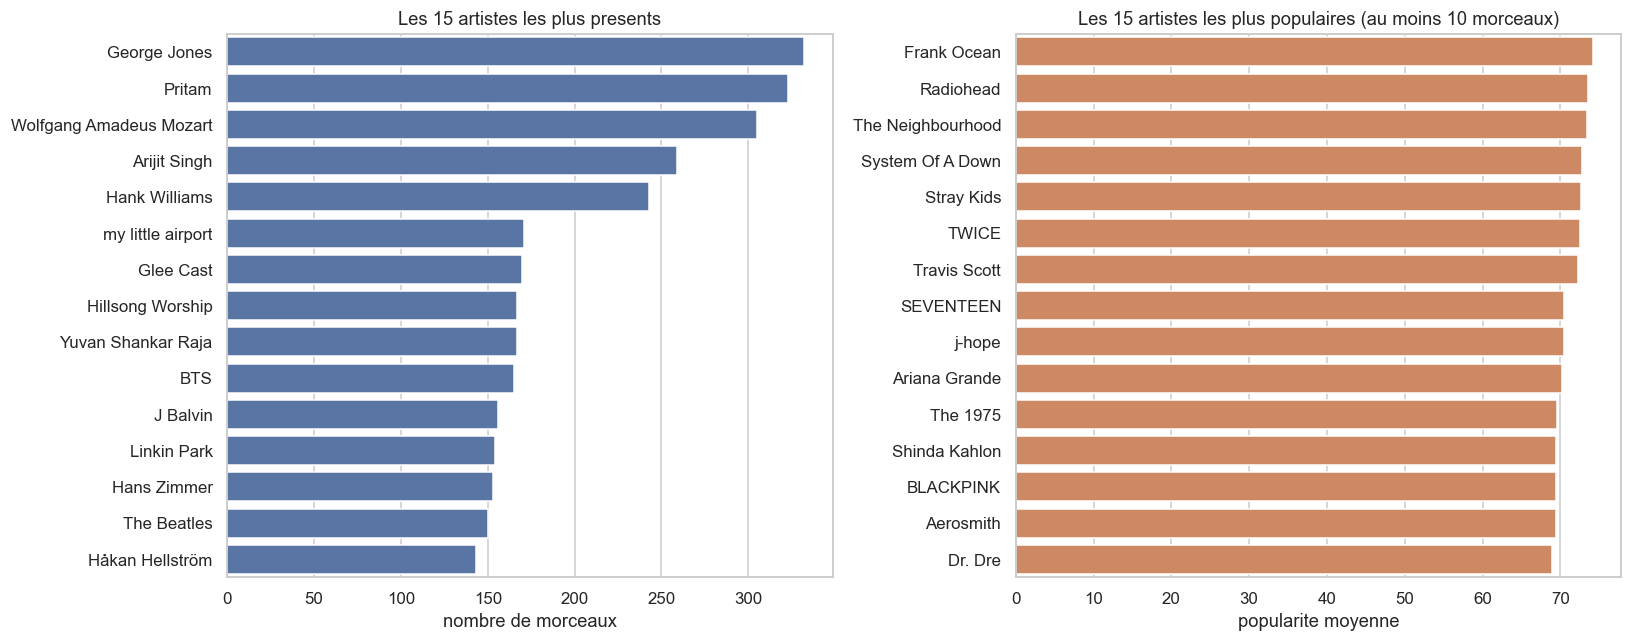

2717 artistes sur 29858 ont au moins 10 morceaux


,les plus presents,nb de morceaux,les plus ecoutes,popularite moyenne
0,George Jones,332,Frank Ocean,74.1
1,Pritam,323,Radiohead,73.5
2,Wolfgang Amadeus Mozart,305,The Neighbourhood,73.5
3,Arijit Singh,259,System Of A Down,72.8
4,Hank Williams,243,Stray Kids,72.6


In [24]:
# les deux classements cote a cote : les plus presents, puis les plus ecoutes
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

top_presents = stats_artistes.nlargest(15, "nb_morceaux")
sns.barplot(x=top_presents.nb_morceaux, y=top_presents.index, ax=axes[0], color="#4C72B0")
axes[0].set_title("Les 15 artistes les plus presents")
axes[0].set_xlabel("nombre de morceaux")

# minimum 10 morceaux, sinon un artiste avec un seul titre a 100 rafle la premiere place
MINI = 10
eligibles = stats_artistes[stats_artistes.nb_morceaux >= MINI]
top_pop = eligibles.nlargest(15, "popularite_moyenne")
sns.barplot(x=top_pop.popularite_moyenne, y=top_pop.index, ax=axes[1], color="#DD8452")
axes[1].set_title(f"Les 15 artistes les plus populaires (au moins {MINI} morceaux)")
axes[1].set_xlabel("popularite moyenne")

for ax in axes:
    ax.set_ylabel("")
plt.tight_layout()
plt.show()

print(f"{len(eligibles)} artistes sur {len(stats_artistes)} ont au moins {MINI} morceaux")

# le detail chiffre : on ne lit pas une valeur precise sur des barres
classements = pd.DataFrame({
    "les plus presents": top_presents.index[:5],
    "nb de morceaux": top_presents.nb_morceaux.values[:5],
    "les plus ecoutes": top_pop.index[:5],
    "popularite moyenne": top_pop.popularite_moyenne.round(1).values[:5],
})
classements

Les artistes sont classés. Reste les morceaux eux-mêmes.


In [25]:
# et les morceaux eux-memes
df_morceaux.nlargest(10, "popularity")[["track_name", "artists", "popularity"]].reset_index(drop=True)

,track_name,artists,popularity
0,Unholy (feat. Kim Petras),Sam Smith;Kim Petras,100
1,"Quevedo: Bzrp Music Sessions, Vol. 52",Bizarrap;Quevedo,99
2,I'm Good (Blue),David Guetta;Bebe Rexha,98
3,La Bachata,Manuel Turizo,98
4,Me Porto Bonito,Bad Bunny;Chencho Corleone,97
5,Tití Me Preguntó,Bad Bunny,97
6,Under The Influence,Chris Brown,96
7,Efecto,Bad Bunny,96
8,I Ain't Worried,OneRepublic,96
9,Ojitos Lindos,Bad Bunny;Bomba Estéreo,95


### Ce que disent les classements

À gauche, des artistes avec un gros stock de titres déjà anciens : George Jones (332 morceaux),
Pritam (323), Mozart (305). Beaucoup de morceaux, peu écoutés aujourd'hui.

À droite, avec le seuil de 10 morceaux : Frank Ocean (75 de moyenne sur 21 titres), Radiohead,
The Neighbourhood, puis des groupes de K-pop. Aucun n'est dans la colonne de gauche.

Le seuil compte : sans lui, un artiste avec un seul titre viral serait premier. Sur 29 858
artistes, 2 717 seulement ont au moins 10 morceaux.

Pour MeloWave : être présent et être écouté sont deux choses différentes. Pousser du volume ne
construit pas d'audience.

### Le profil sonore de quelques genres

Je prends cinq genres volontairement éloignés et je compare leur moyenne sur les six variables qui
vont de 0 à 1. J'écarte le tempo, le loudness et la durée, qui ne sont pas sur cette échelle et
écraseraient le graphique.

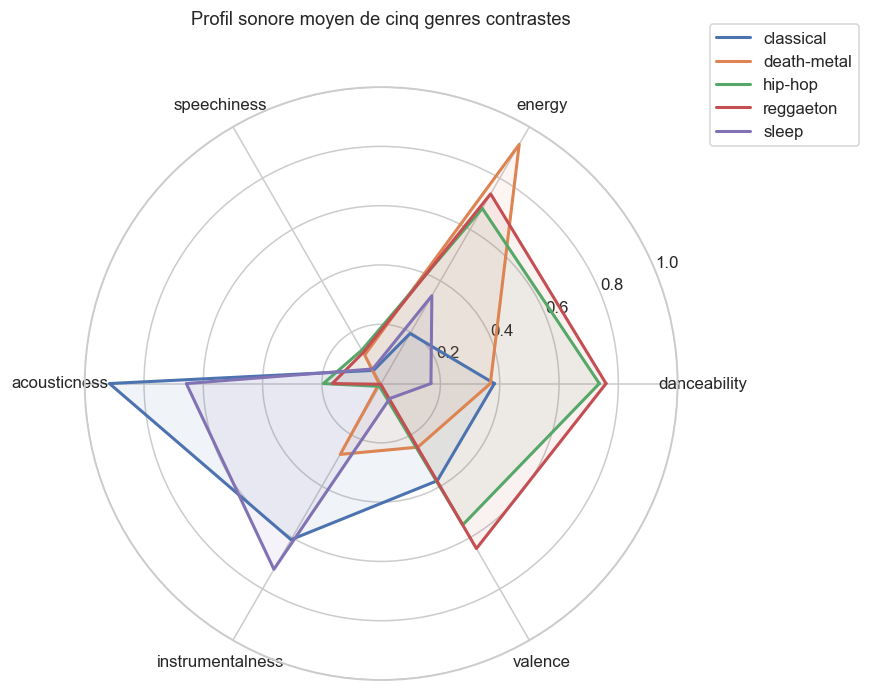

,danceability,energy,speechiness,acousticness,instrumentalness,valence
track_genre,,,,,,
classical,0.38,0.20,0.05,0.92,0.61,0.38
death-metal,0.37,0.93,0.11,0.01,0.28,0.25
hip-hop,0.74,0.68,0.13,0.20,0.01,0.55
reggaeton,0.76,0.74,0.12,0.16,0.00,0.64
sleep,0.17,0.34,0.06,0.66,0.72,0.06


In [26]:
# radar : le profil sonore moyen de cinq genres volontairement eloignes
GENRES_RADAR = ["classical", "death-metal", "hip-hop", "reggaeton", "sleep"]
AXES_RADAR = ["danceability", "energy", "speechiness", "acousticness", "instrumentalness", "valence"]

profils = (df_genre[df_genre.track_genre.isin(GENRES_RADAR)]
           .groupby("track_genre")[AXES_RADAR].mean())

angles = np.linspace(0, 2 * np.pi, len(AXES_RADAR), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
for genre, ligne in profils.iterrows():
    valeurs = ligne.tolist() + [ligne.tolist()[0]]
    ax.plot(angles, valeurs, linewidth=2, label=genre)
    ax.fill(angles, valeurs, alpha=0.08)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(AXES_RADAR)
ax.set_ylim(0, 1)
ax.set_title("Profil sonore moyen de cinq genres contrastes", y=1.09)
ax.legend(loc="upper right", bbox_to_anchor=(1.32, 1.12))
plt.show()

profils.round(2)

### Lecture du radar

Classique et death-metal sont à l'opposé : 0,92 d'acousticness et 0,20 d'énergie d'un côté, 0,01
et 0,93 de l'autre. Ces deux variables suffisent presque à les séparer.

Le genre sommeil est le plus à part : 0,17 de danceability, 0,06 de valence, 0,72
d'instrumentalness. Lent, sans voix, et pas fait pour rendre joyeux.

Le plus intéressant pour MeloWave : hip-hop et reggaeton se superposent presque partout (0,74 et
0,76 de danceability, 0,68 et 0,74 d'énergie). Sur le son seul, on ne les distingue pas. Ce qui
les sépare, c'est la langue et le marché.

### Les morceaux à popularité nulle

14 % des lignes sont à zéro. Avant d'en tirer quoi que ce soit, je regarde où elles se concentrent :
réparties au hasard ou massées sur quelques genres, ça ne se traite pas pareil.

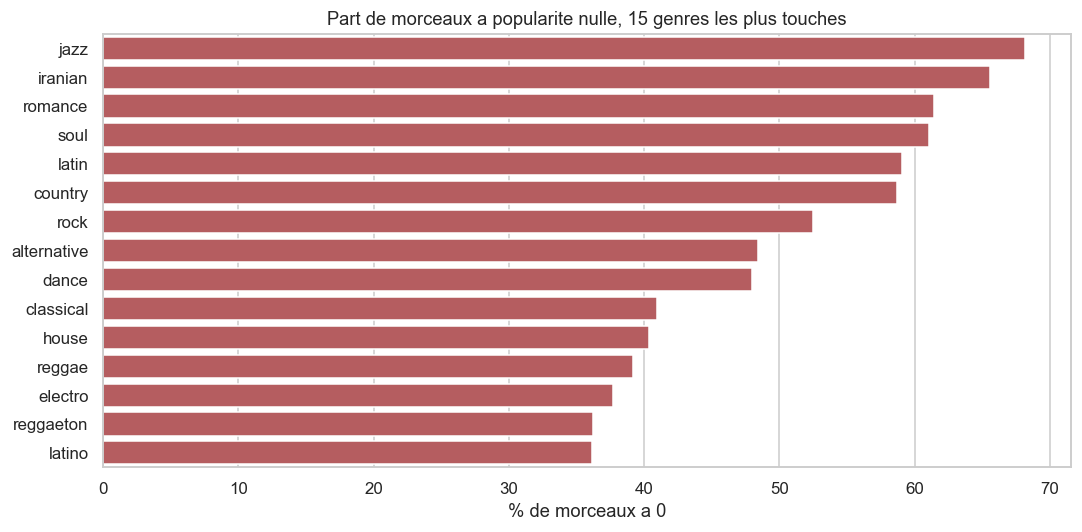

sur l'ensemble du catalogue : 9347 morceaux a popularite nulle, soit 10.4%


In [27]:
# ou se concentrent les morceaux a popularite nulle
df_genre["popularite_nulle"] = df_genre.popularity == 0
zero_par_genre = df_genre.groupby("track_genre").popularite_nulle.mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(x=zero_par_genre.head(15).values * 100,
            y=zero_par_genre.head(15).index, color="#C44E52", ax=ax)
ax.set_title("Part de morceaux a popularite nulle, 15 genres les plus touches")
ax.set_xlabel("% de morceaux a 0")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

n_nulle = (df_morceaux.popularity == 0).sum()
print(f"sur l'ensemble du catalogue : {n_nulle} morceaux a popularite nulle, soit {n_nulle/len(df_morceaux):.1%}")

In [28]:
# le detail chiffre, parce qu'on ne lit pas des valeurs precises sur des barres
detail_zeros = df_genre.groupby("track_genre").agg(
    part_nulle=("popularite_nulle", "mean"),
    mediane=("popularity", "median"),
).sort_values("part_nulle", ascending=False)
detail_zeros["part_nulle"] = (detail_zeros.part_nulle * 100).round(1)
detail_zeros.head(6)

,part_nulle,mediane
track_genre,,
jazz,68.2,0.0
iranian,65.6,0.0
romance,61.4,0.0
soul,61.1,0.0
latin,59.1,0.0
country,58.7,0.0


### Attention à ne pas conclure trop vite
Le jazz est à 68,2 % de morceaux nuls, l'iranien à 65,6 %, le romance à 61,4 %. Ces trois genres
ont aussi une médiane à 0.

On pourrait en déduire que personne n'écoute de jazz. Je ne pense pas. Un score à 0 veut surtout
dire qu'aucune écoute récente n'a été enregistrée sur ce morceau précis. Ça arrive souvent aux
rééditions et aux doublons d'un même enregistrement, très fréquents en jazz et en classique. C'est
le catalogue qui est biaisé, pas le public.

À retenir pour la suite : quand je vais comparer la popularité entre genres, ces zéros vont tirer
certaines moyennes vers le bas. Pour une raison technique, pas musicale.

## 5. Les trois questions du comité

Camille a remonté des questions et demande d'y répondre avec de vrais tests, pas avec des
graphiques.

Ma méthode est la même à chaque fois : je regarde la nature des deux variables, je vérifie les
conditions du test, je pose l'hypothèse nulle, je sors la statistique et la p-value, et je termine
par une phrase que Camille peut lire sans connaître les stats.

Le tableau que j'applique :

| Variables | Test si conditions réunies | Test sinon |
|---|---|---|
| quantitative et quantitative | Pearson | Spearman |
| qualitative et quantitative, 2 groupes | test T de Student | Mann-Whitney U |
| qualitative et quantitative, plus de 2 groupes | ANOVA | Kruskal-Wallis |
| qualitative et qualitative | khi carré | Fisher exact si effectifs trop faibles |



### Est-ce que les variables sont normales ?

Cette question décide de tous les tests qui suivent.

Shapiro-Wilk rejette tout au-delà de quelques milliers de valeurs. Je le lance donc sur 5 000
morceaux tirés au hasard. Le `random_state=42` fait que ce sont toujours les mêmes 5 000 : sans
lui, mes résultats changeraient à chaque exécution du notebook. J'ajoute une droite de Henry, qui
se lit à l'oeil.

In [29]:
ECH = 5000
resultats_normalite = []
for col in ["popularity", "energy", "loudness", "duree_s", "danceability"]:
    echantillon = df_morceaux[col].sample(ECH, random_state=42)
    W, p = stats.shapiro(echantillon)
    resultats_normalite.append({
        "variable": col, "W": round(W, 4), "p-value": f"{p:.2e}",
        "conclusion": "normale" if p > 0.05 else "distribution non normale",
    })
pd.DataFrame(resultats_normalite)

,variable,W,p-value,conclusion
0,popularity,0.9734,1.61e-29,distribution non normale
1,energy,0.9469,3.61e-39,distribution non normale
2,loudness,0.8435,4.77e-57,distribution non normale
3,duree_s,0.7604,4.75e-65,distribution non normale
4,danceability,0.9869,3.49e-21,distribution non normale


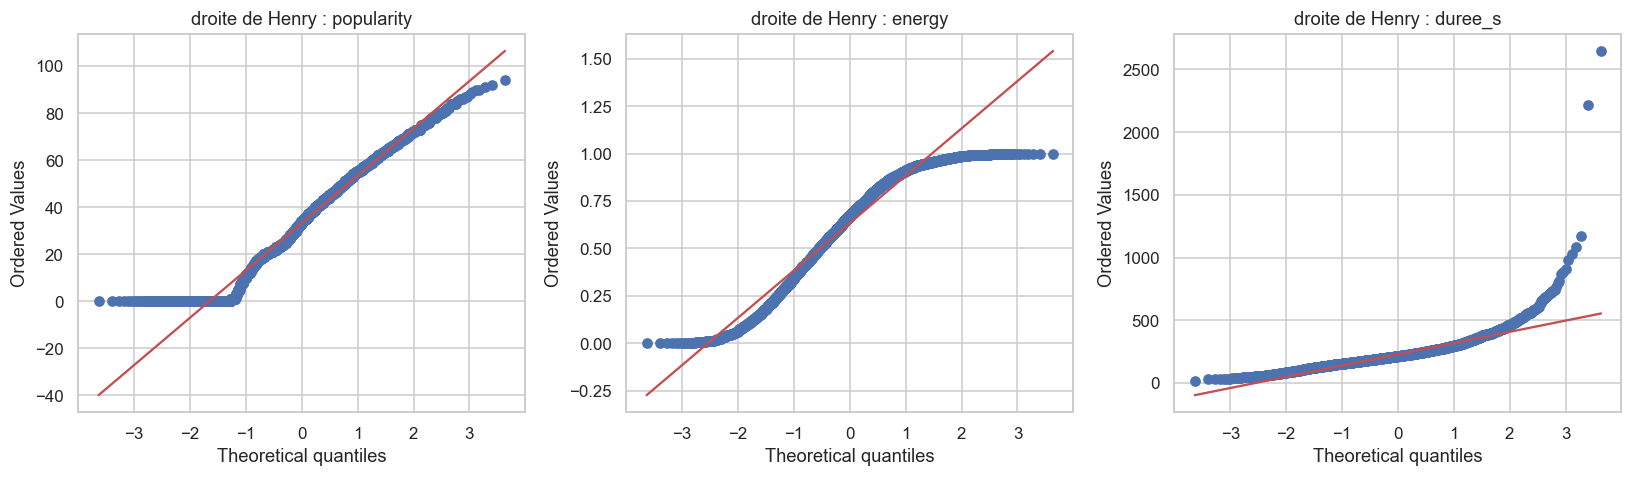

In [30]:
# la droite de Henry : si les points suivent la diagonale, la variable est normale
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, col in zip(axes, ["popularity", "energy", "duree_s"]):
    stats.probplot(df_morceaux[col].sample(ECH, random_state=42), dist="norm", plot=ax)
    ax.set_title(f"droite de Henry : {col}")
plt.tight_layout()
plt.show()

**H0** : la variable suit une loi normale. **Seuil** : 0,05.

Les cinq p-values sont minuscules, la plus grande vaut 2,7e-20. Je rejette H0 à chaque fois.

Les droites de Henry disent la même chose : la popularité reste collée à zéro en bas à gauche, la
durée s'envole à droite, et l'énergie fait un S parce qu'elle ne peut pas descendre sous 0 ni
monter au-dessus de 1.

C'est vrai pour toutes les variables audio : elles vont de 0 à 1, alors qu'une loi normale n'a
aucune limite. Elles ne peuvent donc pas être normales.

**Pour la suite** : je pars sur Spearman et Kruskal-Wallis. Je calculerai quand même les versions
paramétriques à côté, pour montrer que les deux vont dans le même sens.

### Question 1 : les caractéristiques audio sont-elles liées entre elles ?

Deux variables quantitatives, donc une corrélation. Je commence par la vue d'ensemble avant de
zoomer sur le couple le plus fort.

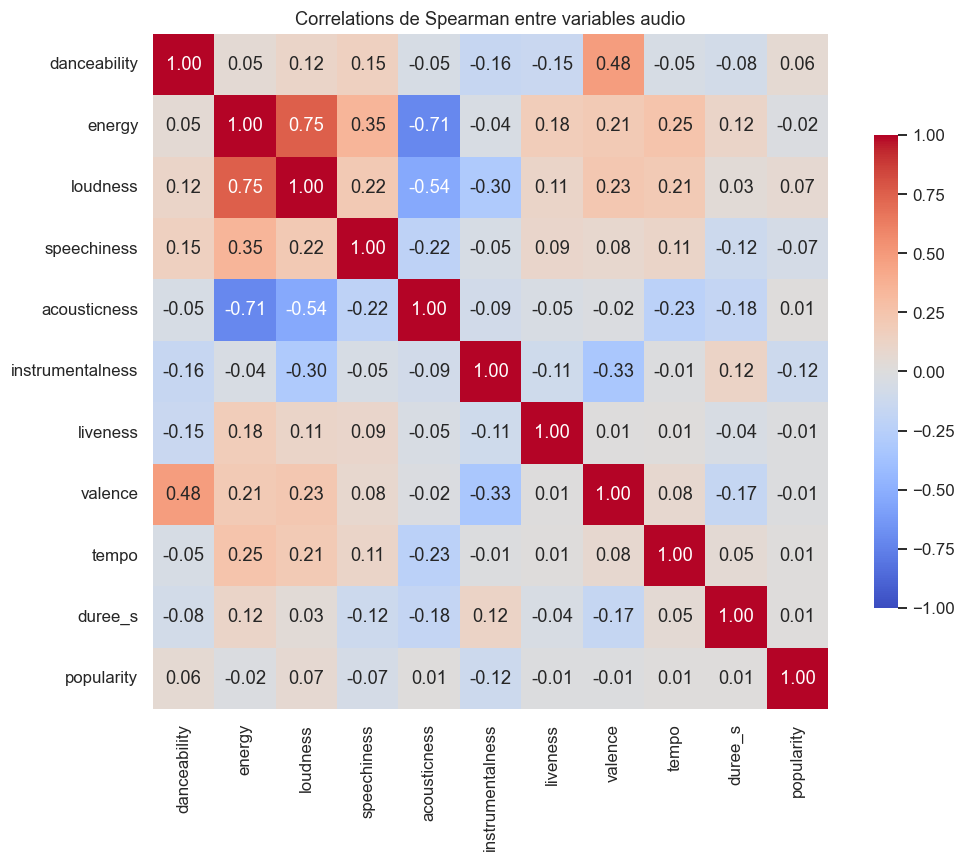

In [31]:
# vue d'ensemble : chaque variable audio croisee avec toutes les autres
corr = df_morceaux[AUDIO + ["popularity"]].corr(method="spearman")

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, vmin=-1, vmax=1, square=True, ax=ax, cbar_kws={"shrink": .7})
ax.set_title("Correlations de Spearman entre variables audio")
plt.tight_layout()
plt.show()

In [32]:
# les liaisons les plus fortes, en valeur absolue
paires = []
for i, a in enumerate(corr.columns):
    for b in corr.columns[i + 1:]:
        paires.append({"variable 1": a, "variable 2": b,
                       "correlation": round(corr.loc[a, b], 3)})

paires = pd.DataFrame(paires)
paires["force"] = paires.correlation.abs()
paires.sort_values("force", ascending=False).drop(columns="force").head(8)

,variable 1,variable 2,correlation
10,energy,loudness,0.753
12,energy,acousticness,-0.712
20,loudness,acousticness,-0.537
6,danceability,valence,0.477
11,energy,speechiness,0.351
41,instrumentalness,valence,-0.334
21,loudness,instrumentalness,-0.299
16,energy,tempo,0.250


Vue d'ensemble faite, je passe au test proprement dit sur le couple le plus fort.


Pearson  : r = 0.7588  p = 0  r2 = 0.576
Spearman : rho = 0.7532  p = 0


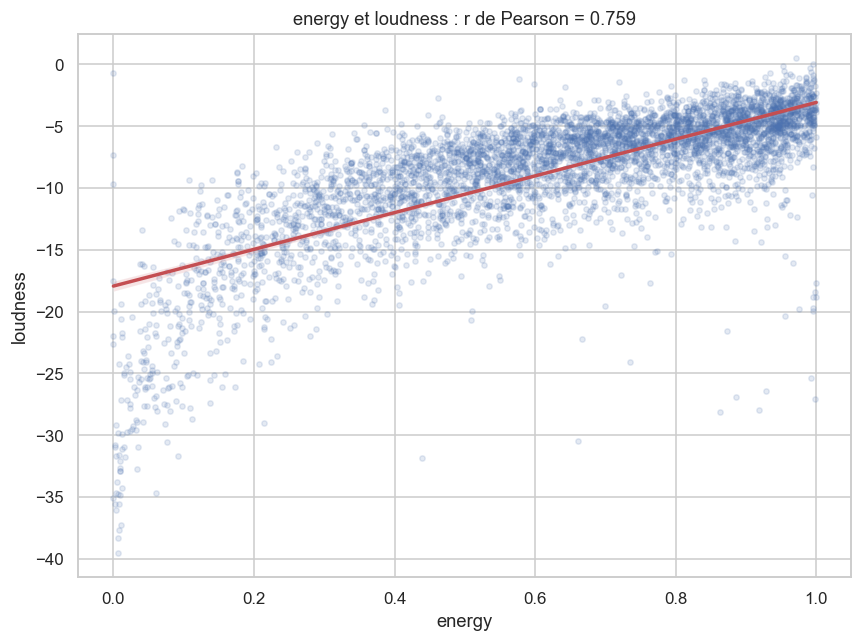

In [33]:
# le couple le plus fort : energy et loudness
r_pearson, p_pearson = stats.pearsonr(df_morceaux.energy, df_morceaux.loudness)
r_spearman, p_spearman = stats.spearmanr(df_morceaux.energy, df_morceaux.loudness)

print(f"Pearson  : r = {r_pearson:.4f}  p = {p_pearson:.3g}  r2 = {r_pearson**2:.3f}")
print(f"Spearman : rho = {r_spearman:.4f}  p = {p_spearman:.3g}")

# un echantillon pour le nuage, sinon 90 000 points font une tache illisible
ech = df_morceaux.sample(5000, random_state=42)
fig, ax = plt.subplots(figsize=(8, 6))
sns.regplot(data=ech, x="energy", y="loudness", ax=ax,
            scatter_kws={"alpha": .15, "s": 12}, line_kws={"color": "#C44E52"})
ax.set_title(f"energy et loudness : r de Pearson = {r_pearson:.3f}")
plt.tight_layout()
plt.show()

**H0** : il n'y a pas de lien entre energy et loudness. **Seuil** : 0,05.

Résultat : r = 0,759, p affichée à 0. Je rejette H0.

Taille d'effet : Spearman donne 0,753, le test que j'ai retenu puisque la normalité est rejetée.
C'est un lien fort. Le carré du r de Pearson vaut 0,576 : les deux variables partagent donc environ
58 % de leur variation.

Les autres liens vont dans le même sens : energy et acousticness à -0,712, danceability et valence
à 0,477.

Réponse à la question 1 : oui, elles sont liées. Certaines se répètent presque, comme l'énergie et
le volume.

### Question 2 : la popularité diffère-t-elle vraiment selon le genre ?

In [34]:
# la popularite change-t-elle d'un genre a l'autre ? je verifie d'abord les conditions
groupes = []
for nom, sous_tableau in df_genre.groupby("track_genre"):
    groupes.append(sous_tableau.popularity.values)

# l'etoile deballe la liste : levene recoit les 114 groupes separement
stat_levene, p_levene = stats.levene(*groupes)
verdict = "variances comparables" if p_levene > .05 else "variances inegales"
print(f"Levene   : stat = {stat_levene:.1f}  p = {p_levene:.3g}  -> {verdict}")

F, p_anova = stats.f_oneway(*groupes)
H, p_kruskal = stats.kruskal(*groupes)

n = len(df_genre)     # nombre de lignes
k = len(groupes)      # nombre de genres
ddl_inter = k - 1
ddl_intra = n - k

# taille d'effet : la part de l'ecart de popularite expliquee par le genre
eta2 = (F * ddl_inter) / (F * ddl_inter + ddl_intra)   # va avec l'ANOVA
epsilon2 = (H - k + 1) / (n - k)                       # va avec Kruskal-Wallis

print(f"\nANOVA    : F = {F:.1f}  p = {p_anova:.3g}  eta2 = {eta2:.3f}")
print(f"Kruskal  : H = {H:.1f}  p = {p_kruskal:.3g}  epsilon2 = {epsilon2:.3f}")

Levene   : stat = 254.4  p = 0  -> variances inegales

ANOVA    : F = 338.3  p = 0  eta2 = 0.252
Kruskal  : H = 30955.3  p = 0  epsilon2 = 0.272


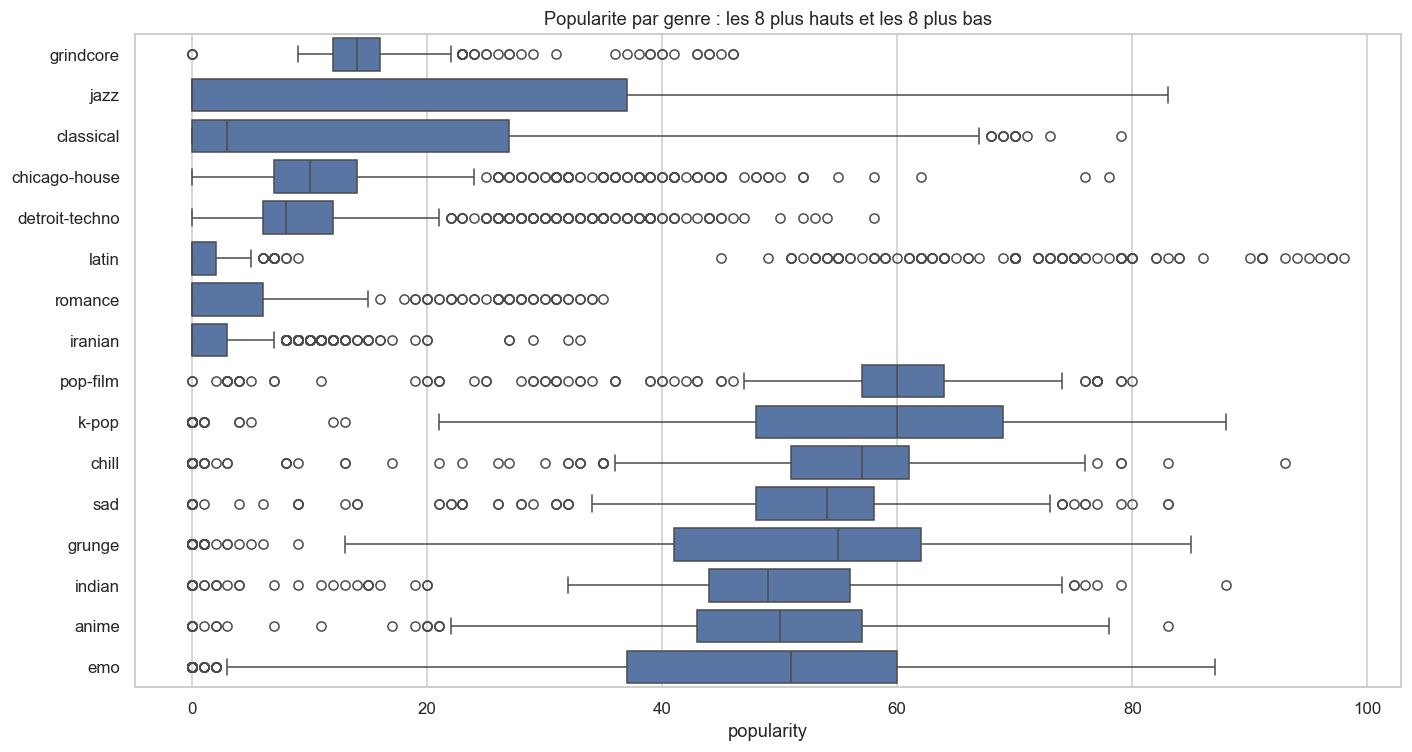

In [35]:
# 8 genres en haut, 8 en bas, sinon 114 boites sont illisibles
moyennes = df_genre.groupby("track_genre").popularity.mean().sort_values()
selection = list(moyennes.tail(8).index) + list(moyennes.head(8).index)

fig, ax = plt.subplots(figsize=(13, 7))
sns.boxplot(data=df_genre[df_genre.track_genre.isin(selection)],
            y="track_genre", x="popularity", order=selection[::-1], ax=ax)
ax.set_title("Popularite par genre : les 8 plus hauts et les 8 plus bas")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

**H0** : tous les genres ont la même popularité moyenne. **Seuil** : 0,05.

Levene sort une p-value nulle : les genres sont dispersés de façon très inégale. Une condition de
l'ANOVA n'est pas remplie, la courbe en cloche non plus. Je retiens Kruskal-Wallis, qui n'exige ni
l'une ni l'autre.

**Résultat** : H = 30 955, p inférieure à 0,001. Je rejette H0. L'ANOVA va dans le même sens.

**Taille d'effet** : epsilon carré = 0,272. Sur tout l'écart de popularité entre morceaux, environ
27 % vient des différences entre genres. Le reste vient des écarts à l'intérieur d'un même genre.
Sur des données réelles, c'est fort.

**Une réserve** : les genres en bas du classement sont ceux où j'ai trouvé le plus de popularités
nulles. Une partie de l'écart vient donc de la façon dont le catalogue a été constitué, pas
seulement du goût du public. Je ne classerais pas les genres du meilleur au pire sur cette base.

**Réponse à la Question 2** : oui, le genre pèse lourd, environ un quart de l'écart entre morceaux.

### Question 3 : le contenu explicite dépend-il du genre ?

Deux variables qualitatives, donc un khi carré. Sa condition d'utilisation est que les effectifs
attendus soient suffisants, en général au moins 5 par case. Je le vérifie avant de lire le
résultat.

In [36]:
# croisement du genre et du caractere explicite
contingence = pd.crosstab(df_genre.track_genre, df_genre.explicit)
chi2, p_chi2, ddl, attendus = stats.chi2_contingency(contingence)

cramer = np.sqrt(chi2 / (contingence.values.sum() * (min(contingence.shape) - 1)))

print(f"cases dont l'effectif attendu est inferieur a 5 : {(attendus < 5).sum()} sur {attendus.size}")
print(f"\nkhi2 = {chi2:.1f}  ddl = {ddl}  p = {p_chi2:.3g}")
print(f"V de Cramer = {cramer:.3f}")
print(f"\ntaux de morceaux explicites sur tout le catalogue : {df_genre.explicit.mean():.2%}")

contingence.head()

cases dont l'effectif attendu est inferieur a 5 : 0 sur 228

khi2 = 18362.1  ddl = 113  p = 0
V de Cramer = 0.402

taux de morceaux explicites sur tout le catalogue : 8.56%


explicit,False,True
track_genre,,
acoustic,948,52
afrobeat,981,18
alt-rock,943,56
alternative,835,164
ambient,994,5


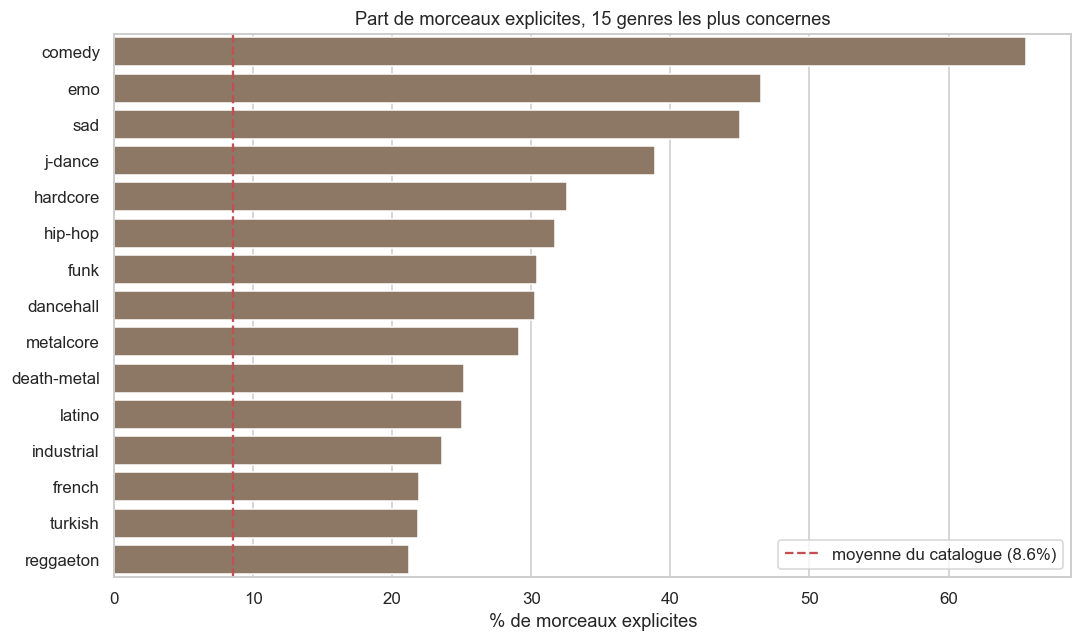

genres sans aucun morceau explicite : 8


,part explicite en %
track_genre,
comedy,65.6
emo,46.5
sad,45.0
j-dance,38.9
hardcore,32.5
hip-hop,31.7


In [37]:
# les genres les plus concernes, compares a la moyenne du catalogue
part_explicite = df_genre.groupby("track_genre").explicit.mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=part_explicite.head(15).values * 100,
            y=part_explicite.head(15).index, color="#937860", ax=ax)
ax.axvline(df_genre.explicit.mean() * 100, color="#C44E52", ls="--",
           label=f"moyenne du catalogue ({df_genre.explicit.mean():.1%})")
ax.set_title("Part de morceaux explicites, 15 genres les plus concernes")
ax.set_xlabel("% de morceaux explicites")
ax.set_ylabel("")
ax.legend()
plt.tight_layout()
plt.show()

print("genres sans aucun morceau explicite :", (part_explicite == 0).sum())

# le detail chiffre des genres les plus concernes
(part_explicite.head(6) * 100).round(1).to_frame("part explicite en %")

## 6. Ce que je retiens pour MeloWave

Le fichier est propre : 450 doublons stricts et une ligne sans titre ni durée, soit 0,4 % du volume. Le vrai sujet
était ailleurs, dans les 16 299 morceaux rangés dans plusieurs genres. Leurs caractéristiques audio
sont identiques d'une ligne à l'autre, je les ai donc gardés et j'ai travaillé à deux niveaux selon
la question posée.

Sur le catalogue, être présent et être écouté sont deux choses différentes : aucun des quinze
artistes les plus présents n'est dans les quinze les plus écoutés. Les caractéristiques audio se
répètent beaucoup, trois d'entre elles suffisent presque à décrire un morceau. Et 9 347 morceaux
ont une popularité nulle, surtout en jazz, en classique et en musiques du monde, ce qui ressemble
plus à un biais de collecte qu'à un désamour du public.

Les trois questions du comité reçoivent trois fois la même réponse, oui, mais l'important est
l'ampleur du lien :

| Question | Test retenu | Taille d'effet |
|---|---|---|
| Les variables audio sont-elles liées ? | Spearman | 0,753 entre energy et loudness |
| La popularité diffère-t-elle selon le genre ? | Kruskal-Wallis | epsilon2 = 0,27 |
| L'explicite dépend-il du genre ? | khi carré | V de Cramér = 0,40 |

Avec 113 549 lignes, les trois p-values tombent à zéro. Elles ne prouvent rien à elles seules, ce
sont les tailles d'effet qui montrent que ces liens comptent vraiment.

Il y a deux choses que ces données ne permettent pas de dire. Rien sur le temps d'abord : ce
fichier est une photo, pas un film, je ne sais pas si un genre monte ou descend. Et aucun lien de
cause à effet : le genre est lié à la popularité, mais changer de genre ne rendra pas un artiste
populaire.
